In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500

In [2]:
# Datos sintéticos

MedInc = np.random.lognormal(mean=2.5, sigma=0.35, size=n)
HouseAge = np.random.randint(1, 52, size=n)
Longitude = -1254 + np.random.rand(n) * 10 
Latitude = 32 + np.random.rand(n) * 8
AveRooms = 5 + 0.15*MedInc + 0.3*HouseAge + np.random.rand(n)

# target
target = (
    0.45*MedInc
    - 0.2*HouseAge
    -0.3*(Latitude-36)
    -0.1*(Longitude+119)
    + np.random.rand(n)*0.5
)

df = pd.DataFrame(
    {
        "MedInc": MedInc,
        "House_Age": HouseAge,
        "Longitude" : Longitude,
        "Latitude" : Latitude,
        "AveRooms" : AveRooms,
        "Target" : target
    }
)

numeric_cols = df.columns.tolist()

In [3]:
cov_mat = df[numeric_cols].cov()
corr_mat = df[numeric_cols].corr()

print("Covariance Matrix", cov_mat.round(3))
print("Correlation Matrix", corr_mat.round(3))

Covariance Matrix            MedInc  House_Age  Longitude  Latitude  AveRooms  Target
MedInc     22.967     -3.196      0.114     0.694     2.386  10.767
House_Age  -3.196    222.304     -2.162    -0.080    66.078 -45.827
Longitude   0.114     -2.162      8.644     0.390    -0.620  -0.478
Latitude    0.694     -0.080      0.390     5.031     0.090  -1.211
AveRooms    2.386     66.078     -0.620     0.090    20.212 -12.157
Target     10.767    -45.827     -0.478    -1.211   -12.157  14.478
Correlation Matrix            MedInc  House_Age  Longitude  Latitude  AveRooms  Target
MedInc      1.000     -0.045      0.008     0.065     0.111   0.590
House_Age  -0.045      1.000     -0.049    -0.002     0.986  -0.808
Longitude   0.008     -0.049      1.000     0.059    -0.047  -0.043
Latitude    0.065     -0.002      0.059     1.000     0.009  -0.142
AveRooms    0.111      0.986     -0.047     0.009     1.000  -0.711
Target      0.590     -0.808     -0.043    -0.142    -0.711   1.000


In [4]:
# Hat-Matrix

y = df["Target"].values.reshape(-1,1)
X = df[["MedInc", "House_Age", "Longitude", "Latitude", "AveRooms"]].values



In [5]:
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
beta = XtX_inv @ X.T @ y
y_hat = X @ beta 

resid = y - y_hat

#Hat Matrix
H = X @ XtX_inv @ X.T
leverage = np.diag(H)
print(leverage)

[0.00630043 0.00780624 0.00726231 0.01545779 0.00488905 0.00856724
 0.01438573 0.00768128 0.01373022 0.0114175  0.00751682 0.01097288
 0.00246821 0.0092612  0.01020982 0.00451373 0.00464599 0.00971335
 0.01206332 0.01402262 0.00915066 0.01016173 0.00793992 0.00705952
 0.01229912 0.00269616 0.01406697 0.00790172 0.01091701 0.00336037
 0.01022962 0.02415305 0.00780109 0.01430573 0.01295063 0.01285373
 0.00632906 0.01145656 0.01369766 0.00413973 0.00719538 0.00793365
 0.00870975 0.00924729 0.00794906 0.00929808 0.00775764 0.01352249
 0.01015396 0.018705   0.00426443 0.00325053 0.00825477 0.00610336
 0.01156396 0.0108124  0.00971896 0.00852176 0.00271032 0.01463862
 0.00679265 0.004777   0.01218579 0.00716149 0.00534693 0.01942854
 0.01498679 0.00606888 0.01455145 0.01254705 0.00695925 0.01689636
 0.00394919 0.01183268 0.01742393 0.01417961 0.00396693 0.00789013
 0.01161392 0.00684429 0.00837998 0.00890642 0.01958579 0.0043222
 0.0091762  0.00550637 0.0082146  0.00665889 0.00944208 0.00358

In [6]:
n, p = X.shape
print("n", n)
print("p", p)

avg_lev = p/n
threshold = 2*avg_lev
print("avg_lev", avg_lev)
print("threshold", threshold)

n 500
p 5
avg_lev 0.01
threshold 0.02


In [7]:
summary = pd.DataFrame({
    "index": np.arange(n),
    "leverage": leverage, 
    "y": y.flatten(),
    "y_hat": y_hat.flatten(),
    "resid":resid.flatten()
})

In [8]:
print("Top Ten Leverage Points")
print(summary.sort_values(by="leverage", ascending=False).head(10).round(3))

Top Ten Leverage Points
     index  leverage        y    y_hat  resid
209    209     0.114  134.688  134.553  0.135
478    478     0.051  126.201  126.115  0.085
179    179     0.033  121.676  121.503  0.172
113    113     0.028  118.937  118.840  0.098
234    234     0.027  115.129  115.104  0.025
252    252     0.027  116.294  116.127  0.168
220    220     0.027  121.471  121.378  0.092
284    284     0.025  122.870  122.743  0.127
31      31     0.024  121.800  121.867 -0.067
393    393     0.022  115.107  115.231 -0.124


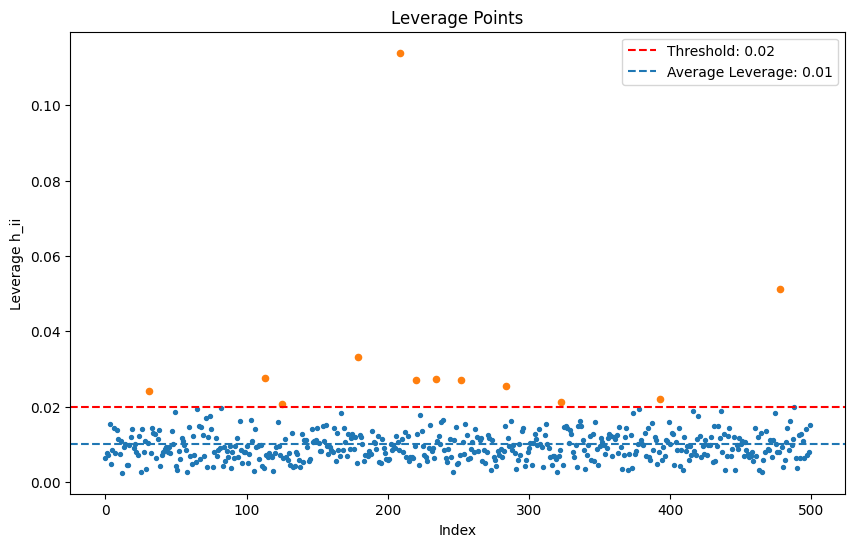

In [9]:
#Plotting leverage 
plt.figure(figsize=(10,6))
plt.scatter(summary["index"], summary["leverage"], s=8)
plt.axhline(threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.2f}')
plt.axhline(avg_lev, linestyle='--', label=f'Average Leverage: {avg_lev:.2f}')
hi_idx = summary.index[summary["leverage"]> threshold].tolist()
if len(hi_idx) > 0: 
    plt.scatter(hi_idx, summary.loc[hi_idx, "leverage"], s=20)
plt.title("Leverage Points")
plt.xlabel("Index")
plt.ylabel("Leverage h_ii")
plt.legend()
plt.show()





In [10]:
# Leverage points

import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [11]:
# Generate synthetic data
np.random.seed(0)

# Normal house
house_size = np.random.normal(2000, 400, 100)
house_price = 100 + 0.5 * house_size + np.random.normal(0, 2000, 100)

# Add few mansion 
house_size = np.append(house_size, [5000, 6000, 7000])
house_price = np.append(house_price, [450000, 550000, 800000])

# Fit a linear regression model 
X = sm.add_constant(house_size)
model = sm.OLS(house_price, X).fit()






In [12]:
# Printing model parameter
print("Model with mansions: ")

print(f"Intercept: {model.params[0]:.2f}")
print(f"Slope: {model.params[1]:.2f}") # es lo que es + b (de la recta)

Model with mansions: 
Intercept: -224250.52
Slope: 113.55


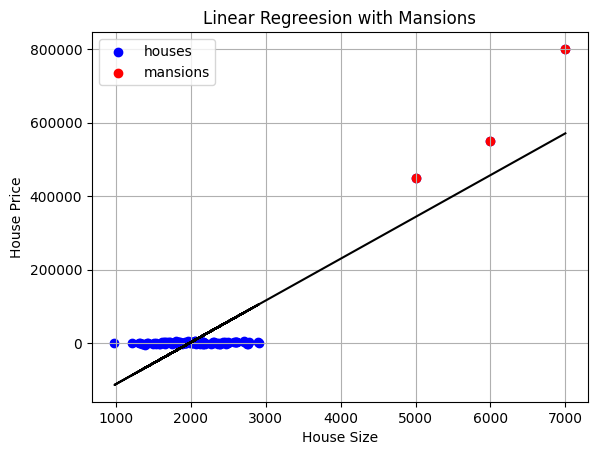

In [13]:
# Plot the data
plt.scatter(house_size, house_price, label='houses', color="blue")
plt.scatter(house_size[-3:], house_price[-3:], label='mansions', color="red")
plt.plot(house_size, model.params[0] + model.params[1] * house_size, color='black')
plt.title('Linear Regreesion with Mansions')
plt.xlabel('House Size')
plt.ylabel('House Price')
plt.legend()
plt.grid(True)
plt.show()

Habría ahora que ver qué pasa con las casas de esos tamaños, para ver si sí es cierto qu están afuera

In [14]:
# Get the leverage points 

influence = model.get_influence() # automáticamente la biblioteca 
leverage = influence.hat_matrix_diag 
residuals = model.resid

# Threshold
n = len(house_size)
p = X.shape[1]
avg_lev = p/n
threshold = 2 * avg_lev
print(threshold)

0.038834951456310676


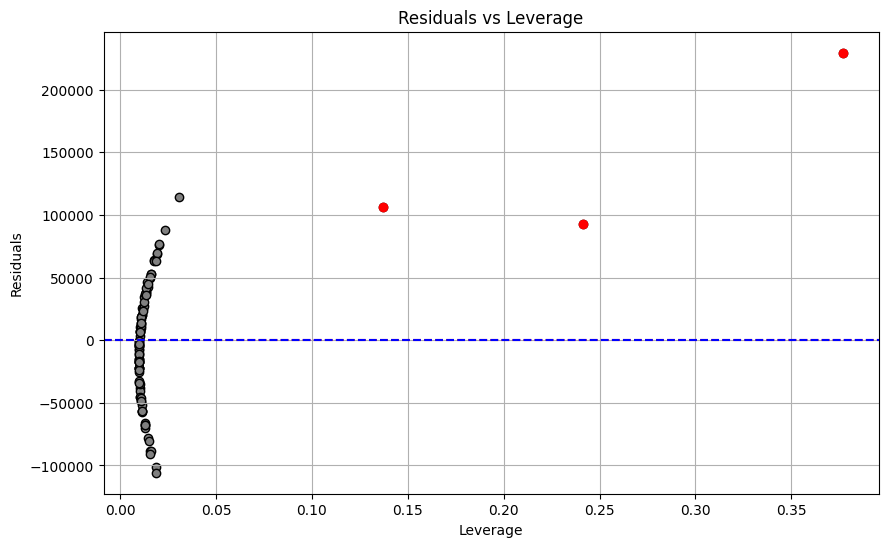

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(leverage, residuals, edgecolors='k', facecolor='gray')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(threshold, color='b', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Residuals vs Leverage')
plt.grid(True)

high_leverage_points = np.where(leverage > threshold)[0]
plt.scatter(leverage[high_leverage_points], 
            residuals[high_leverage_points], 
            color='red', 
            label='High Leverage Points')
plt.show()

In [16]:
print(f"High leverage points (index): {high_leverage_points}")
print(f"Leverage points: {leverage[high_leverage_points]}")


High leverage points (index): [100 101 102]
Leverage points: [0.13694378 0.24146323 0.37708716]


Exercise 1. 
Use the Boston Houusing dataset, analyze it, and identify its leverage points. This dataset is available in the seaborn library.

In [33]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [34]:
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS",
    "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]
df = pd.DataFrame(data, columns=columns)

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [35]:
X = df
y = target

In [36]:
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Thu, 09 Oct 2025   Prob (F-statistic):          6.72e-135
Time:                        08:39:52   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.0

In [37]:
# Get influence measures
influence = model.get_influence()
leverage = influence.hat_matrix_diag
residuals = model.resid

# Threshold
n = X.shape[0]
p = X.shape[1]
avg_lev = p/n
threshold = 2 * avg_lev
print(threshold)



0.05138339920948617


In [38]:
# Intercept term
X_mat = np.hstack([np.ones((X.shape[0], 1)), X.values])

# Compute hat matrix
H = X_mat @ np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T
leverage = np.diag(H)

In [39]:
# Printing model parameter
print("Model with mansions: ")

print(f"Intercept: {model.params[0]:.2f}")
print(f"Slope: {model.params[1]:.2f}")

Model with mansions: 
Intercept: 36.46
Slope: -0.11


/var/folders/0b/36rw0ltd0vg3t22nhv3dkq0r0000gn/T/ipykernel_5027/4029489841.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Intercept: {model.params[0]:.2f}")
/var/folders/0b/36rw0ltd0vg3t22nhv3dkq0r0000gn/T/ipykernel_5027/4029489841.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.2f}")


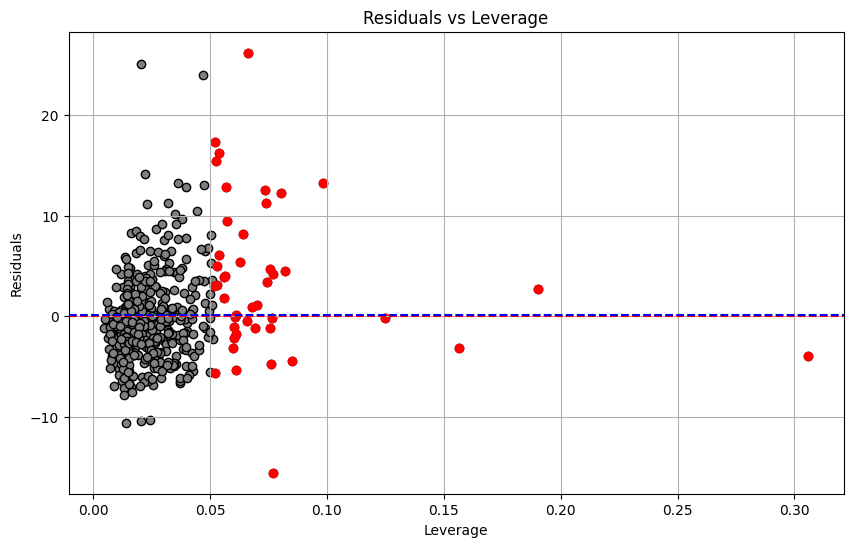

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(leverage, residuals, edgecolors='k', facecolor='gray')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(threshold, color='b', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Residuals vs Leverage')
plt.grid(True)

high_leverage_points = np.where(leverage > threshold)[0]
plt.scatter(leverage[high_leverage_points], 
            residuals[high_leverage_points], 
            color='red', 
            label='High Leverage Points')
plt.show()

In [41]:
print(f"High leverage points (index): {high_leverage_points}")
print(f"Leverage points: {leverage[high_leverage_points]}")

High leverage points (index): [  8 120 121 122 123 124 125 126 142 144 145 147 152 154 155 156 160 162
 163 209 214 253 283 353 354 355 364 365 367 368 369 370 380 405 410 412
 414 418 427 488 489 490 491 492]
Leverage points: [0.05287177 0.06098792 0.06013492 0.06061754 0.06795444 0.06092097
 0.06037207 0.06999688 0.06930322 0.0528894  0.05598942 0.05377772
 0.07613859 0.06130131 0.08527666 0.06589052 0.0519746  0.05741897
 0.06425294 0.05172053 0.07340449 0.05684161 0.06285775 0.07557389
 0.05607539 0.05626903 0.07672256 0.09851493 0.08043019 0.06633094
 0.05197883 0.05276017 0.30595949 0.15643251 0.12470699 0.05392577
 0.07387175 0.19010096 0.05961995 0.07420861 0.07570886 0.08206742
 0.07645812 0.07711251]


Exercise 2: 
Use the diamonds dataset, analyze it, and identify its leverage. This dataset is available in the seaborn library. 

In [44]:
import seaborn as sns
df = sns.load_dataset('diamonds')
print(df.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [45]:
X = df.drop(columns=['price']).select_dtypes(include=[np.number])
y = df['price']

In [46]:
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                 5.486e+04
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:53:27   Log-Likelihood:            -4.7090e+05
No. Observations:               53940   AIC:                         9.418e+05
Df Residuals:                   53933   BIC:                         9.419e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.085e+04    447.562     46.584      0.0

In [48]:
influence = model.get_influence()
leverage = influence.hat_matrix_diag
residuals = model.resid

n = X.shape[0]
p = X.shape[1]
avg_lev = p / n
threshold = 2 * avg_lev

In [49]:
# Intercept term
X_mat = np.hstack([np.ones((X.shape[0], 1)), X.values])

# Compute hat matrix
H = X_mat @ np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T
leverage = np.diag(H)

print("Model with mansions: ")

print(f"Intercept: {model.params[0]:.2f}")
print(f"Slope: {model.params[1]:.2f}")

Model with mansions: 
Intercept: 20849.32
Slope: 10686.31


/var/folders/0b/36rw0ltd0vg3t22nhv3dkq0r0000gn/T/ipykernel_5027/1755888953.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Intercept: {model.params[0]:.2f}")
/var/folders/0b/36rw0ltd0vg3t22nhv3dkq0r0000gn/T/ipykernel_5027/1755888953.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.2f}")


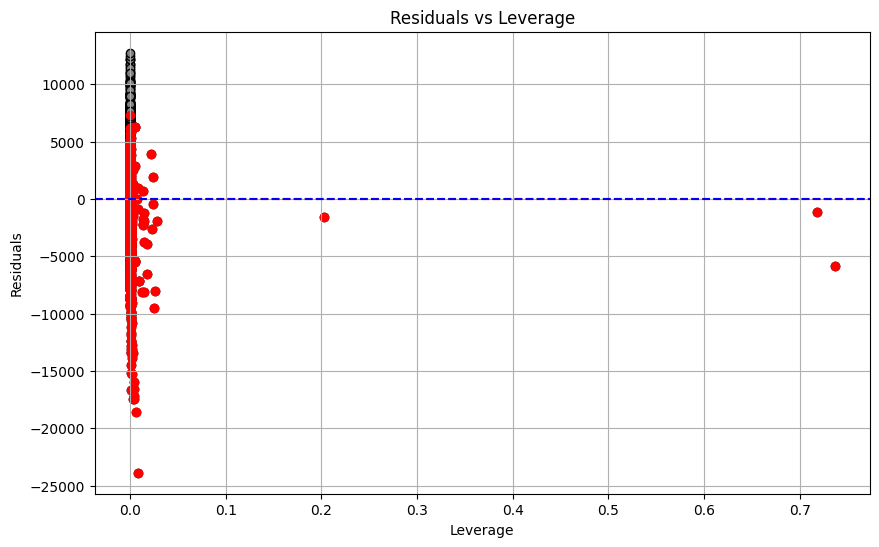

In [50]:
plt.figure(figsize=(10, 6))
plt.scatter(leverage, residuals, edgecolors='k', facecolor='gray')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(threshold, color='b', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Residuals vs Leverage')
plt.grid(True)

high_leverage_points = np.where(leverage > threshold)[0]
plt.scatter(leverage[high_leverage_points], 
            residuals[high_leverage_points], 
            color='red', 
            label='High Leverage Points')
plt.show()

In [51]:
print(f"High leverage points (index): {high_leverage_points}")
print(f"Leverage points: {leverage[high_leverage_points]}")

High leverage points (index): [    1     2     8 ... 53863 53890 53897]
Leverage points: [0.00022606 0.00050797 0.00034393 ... 0.00027142 0.0002524  0.00026746]
